# Joint vs per-bin Fisher matrix comparison

This notebook verifies that two equivalent approaches to multi-bin Fisher forecasts
yield the same cosmological constraints:

**Method A — Joint Fisher matrix** 
Build a single large Fisher matrix from the joint data vector across all bins
(with block-diagonal covariance). Marginalize over all nuisance parameters at the end.

**Method B — Per-bin Fisher matrices** 
For each bin, build an individual Fisher matrix (cosmo + survey), marginalize over
the per-bin survey/EFT parameters, then sum the resulting cosmo-only Fisher matrices:
$$
F_{ij}^{\rm cosmo} = \sum_{b=1}^{N_{\rm bins}} \left[ F^{(b)}_{\rm marg} \right]_{ij}
$$
This is valid because (i) the covariance is block-diagonal across bins, and
(ii) survey/EFT nuisance parameters are independent per bin.

## Modules

In [1]:
import os

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

import numdifftools as nd
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy as jsp
from jax.scipy.linalg import block_diag, inv

### background cosmology

from ps_1loop_jax import background as bg

### jaxptpolypol

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import (fisher_matrix, marginalize_fisher,
                                     sigma_from_fisher, fixed_and_varied_indices)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Initialize emulators and model

In [2]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'

pklin_emulator = CosmoEmulator(
    emulator_path=model_path,
    emulator_params=['ombh2', 'omch2', 'logA', 'ns', 'h', 'z', 'A_b', 'eta_b', 'logT_AGN', 'mnu'],
)
ps1loop_model = PS1LoopModel()

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


## Fiducial cosmology

In [3]:
cosmo_dict = {
    'ombh2':    0.02242,
    'omch2':    0.11933,
    'logA':     3.047,
    'ns':       0.9665,
    'h':        0.6766,
    'z':        0.7,       # placeholder; overridden per bin
    'A_b':      3.13,
    'eta_b':    0.603,
    'logT_AGN': 7.8,
    'mnu':      0.06,
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  logA: 3.047
  ns: 0.9665
  h: 0.6766
  z: 0.7
  A_b: 3.13
  eta_b: 0.603
  logT_AGN: 7.8
  mnu: 0.06


## Survey specifications per bin

In [4]:
# PFS redshift bins
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))  # [Mpc/h]^3
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)  # [h/Mpc]
n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)  # [h/Mpc]^3
n_zbins  = len(z_bins)

print(f"Number of redshift bins: {n_zbins}")
for i, (z, V, knl, nd) in enumerate(zip(z_bins, V_bins, knl_bins, n_bins)):
    print(f"  Bin {i+1}: z={z}, V={V/1e9:.2f} (Gpc/h)^3, knl={knl}, ndens={nd:.2e}")

Number of redshift bins: 7
  Bin 1: z=0.7, V=0.59 (Gpc/h)^3, knl=0.52, ndens=3.06e-04
  Bin 2: z=0.9, V=0.79 (Gpc/h)^3, knl=0.65, ndens=9.61e-04
  Bin 3: z=1.1, V=0.96 (Gpc/h)^3, knl=0.82, ndens=9.75e-04
  Bin 4: z=1.3, V=1.09 (Gpc/h)^3, knl=1.02, ndens=6.54e-04
  Bin 5: z=1.5, V=1.19 (Gpc/h)^3, knl=1.29, ndens=3.40e-04
  Bin 6: z=1.8, V=2.58 (Gpc/h)^3, knl=1.82, ndens=2.02e-04
  Bin 7: z=2.2, V=2.71 (Gpc/h)^3, knl=2.88, ndens=3.51e-04


In [5]:
# Bias fitting functions from Eq. (3.6)-(3.14) of arXiv:1907.06666
def b1z(z): return 0.9 + 0.4*z
def b2z(z): return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3
def bG2z(z): return -(2./7.)*(b1z(z) - 1.)
def bGamma3z(z): return (23./42.)*(b1z(z) - 1.)

# Linear growth factor D+(z) via ps_1loop_jax.background (Heath integral, includes mnu)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z,
        mnu=cosmo_dict['mnu']
    ))

def c0z(z): return 25.*Dplusz(z)**2
def c2z(z): return 25.*Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

In [6]:
# Build role-aware survey params for each bin
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bins)):
    surveys.append(
        FullShapeSurveyParams(
            shared={
                'bias': {
                    'b1':      b1z(z),
                    'b2':      b2z(z),
                    'bG2':     bG2z(z),
                    'bGamma3': bGamma3z(z),
                },
                'stoch': {
                    'P_shot': 1.0,
                },
                'k_nl':  knl,
                'ndens': nd,
            },
            pk={
                'ctr': {
                    'c0':   c0z(z),
                    'c2':   c2z(z),
                    'c4':   c4z(z),
                    'cfog': knl**(-4),
                },
                'stoch': {
                    'a0': 0.,
                    'a2': 0.,
                },
            },
        )
    )

pk_survey_keys = surveys[0].pk_param_keys
print(f"Survey params per bin: {len(pk_survey_keys)}")


Survey params per bin: 13


## Common settings

In [7]:
ells_tuple = (0, 2, 4)
n_ell = len(ells_tuple)
k = jnp.linspace(5e-3, 0.25, 50)
n_k = len(k)
dk = k[1] - k[0]

# Fiducial distances for AP
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins, mnu=cosmo_dict['mnu'])

# Parameter structure
n_cosmo = sum(cosmo.param_sizes)
n_survey = len(pk_survey_keys)

# Fixed parameter indices (within cosmo and survey blocks)
fixed_cosmo_idx = [5, 6, 7, 8]       # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]

# Indices of varied cosmo params (for final comparison)
varied_cosmo_idx = [i for i in range(n_cosmo) if i not in fixed_cosmo_idx]
n_varied_cosmo = len(varied_cosmo_idx)

# Fiducial values for the varied cosmo params (used in contour plots)
packed_cosmo = cosmo.to_array()
fid_cosmo_varied = jnp.array([float(packed_cosmo[i]) for i in varied_cosmo_idx])

cosmo_param_names = (
    r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$',
    r'$n_s$', r'$h$', r'$m_\nu$'
)

print(f"n_cosmo = {n_cosmo}, n_survey = {n_survey}, n_bins = {n_zbins}")
print(f"Varied cosmo indices: {varied_cosmo_idx}")
print(f"Fiducial varied cosmo: {fid_cosmo_varied}")
print(f"Fixed cosmo: z, A_b, eta_b, logT_AGN")
print(f"Fixed survey (per bin): k_nl, ndens")


n_cosmo = 10, n_survey = 13, n_bins = 7
Varied cosmo indices: [0, 1, 2, 3, 4, 9]
Fiducial varied cosmo: [0.02242 0.11933 3.047   0.9665  0.6766  0.06   ]
Fixed cosmo: z, A_b, eta_b, logT_AGN
Fixed survey (per bin): k_nl, ndens


---
# Method A: Joint Fisher matrix

Single differentiable wrapper over all bins, block-diagonal covariance,
one Jacobian, one Fisher matrix, marginalize at the end.

In [8]:
# Multi-bin wrapper
pk_fn_joint = make_pk_ell_fn(
    ells=ells_tuple,
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,

    n_gl=16,
)
jitted_joint = jax.jit(pk_fn_joint)

# Joint parameter vector
packed_joint = pack_pk_params(cosmo, surveys)
print(f"Joint parameter vector: {packed_joint.shape[0]} params")


Joint parameter vector: 101 params


In [9]:
%%time
# Joint Jacobian
jac_joint = jax.jacfwd(jitted_joint, argnums=0)(packed_joint, k=k)
print(f"Joint Jacobian shape: {jac_joint.shape}")

Joint Jacobian shape: (1050, 101)
CPU times: user 7min 52s, sys: 7.52 s, total: 7min 59s
Wall time: 1min


In [10]:
# Block-diagonal covariance
pk_all = jitted_joint(packed_joint, k=k).reshape(n_zbins, n_ell, n_k)

cov_blocks = []
for b in range(n_zbins):
    P0, P2, P4 = pk_all[b]
    cov_blocks.append(gaussian_covariance(V_bins[b], k, dk, P0, P2, P4))

cov_joint = block_diag(*cov_blocks)
print(f"Joint covariance shape: {cov_joint.shape}")

Joint covariance shape: (1050, 1050)


In [11]:
# Joint Fisher matrix
F_joint = fisher_matrix(cov_joint, jac_joint)
print(f"Joint Fisher shape: {F_joint.shape}")

# Marginalize over fixed params
fixed_idx_A, varied_idx_A = fixed_and_varied_indices(
    n_cosmo, n_survey, n_zbins, fixed_cosmo_idx, fixed_survey_offsets
)
F_joint_marg = marginalize_fisher(F_joint, varied_idx_A)
print(f"Marginalized joint Fisher shape: {F_joint_marg.shape}")

# Extract cosmo-only block by inverting, extracting, re-inverting
# (standard Schur complement marginalization over nuisance params)
F_joint_inv = inv(F_joint_marg)

# Map varied cosmo indices to their positions in the marginalized Fisher
cosmo_positions_A = [varied_idx_A.index(i) for i in varied_cosmo_idx]
F_cosmo_A = inv(F_joint_inv[jnp.ix_(jnp.array(cosmo_positions_A), jnp.array(cosmo_positions_A))])

sigma_A = jnp.sqrt(jnp.diag(inv(F_cosmo_A)))
print(f"\nMethod A — cosmo-only Fisher shape: {F_cosmo_A.shape}")

Joint Fisher shape: (101, 101)
Marginalized joint Fisher shape: (83, 83)



Method A — cosmo-only Fisher shape: (6, 6)


---
# Method B: Per-bin Fisher matrices

For each bin independently:
1. Build a single-bin wrapper with `make_pk_ell_fn(z_bins=None)`
2. Compute the per-bin Jacobian and covariance
3. Build the per-bin Fisher matrix (cosmo + survey)
4. Marginalize over survey/EFT nuisance parameters
5. Extract the cosmo-only block

Then sum the cosmo-only Fisher matrices across bins.

In [12]:
# Per-bin varied survey indices (within the single-bin parameter vector)
fixed_survey_in_single = [n_cosmo + s for s in fixed_survey_offsets]
fixed_single = fixed_cosmo_idx + fixed_survey_in_single
varied_single = [i for i in range(n_cosmo + n_survey) if i not in fixed_single]

# Positions of varied cosmo params within the single-bin varied vector
cosmo_positions_single = [varied_single.index(i) for i in varied_cosmo_idx]

print(f"Single-bin total params: {n_cosmo + n_survey}")
print(f"Single-bin varied params: {len(varied_single)}")
print(f"Cosmo positions in varied: {cosmo_positions_single}")


Single-bin total params: 23
Single-bin varied params: 17
Cosmo positions in varied: [0, 1, 2, 3, 4, 5]


In [13]:
%%time
F_cosmo_sum = jnp.zeros((n_varied_cosmo, n_varied_cosmo))
F_cosmo_per_bin = []  # store per-bin cosmo Fisher for plotting

for b in range(n_zbins):
    # 1. Single-bin wrapper (z is read from the cosmo parameter vector)
    pk_fn_b = make_pk_ell_fn(
        ells=ells_tuple,
        pklin_emulator=pklin_emulator,
        ps1loop_model=ps1loop_model,
        cosmo_keys=cosmo.param_keys,
        cosmo_sizes=cosmo.param_sizes,
        survey_keys=surveys[b].pk_param_keys,
        ap=True,
        Hz_fid=(Hz_fid[b],),
        DAz_fid=(DAz_fid[b],),
        n_gl=16,
    )
    jitted_b = jax.jit(pk_fn_b)

    # 2. Pack single-bin parameters (override z to this bin's redshift)
    cosmo_dict_b = dict(cosmo_dict, z=z_bins[b])
    cosmo_b = CosmoParams(cosmo_dict_b)
    packed_b = pack_pk_params(cosmo_b, [surveys[b]])

    # 3. Per-bin Jacobian
    jac_b = jax.jacfwd(jitted_b, argnums=0)(packed_b, k=k)

    # 4. Per-bin covariance
    pk_b = jitted_b(packed_b, k=k).reshape(n_ell, n_k)
    cov_b = gaussian_covariance(V_bins[b], k, dk, pk_b[0], pk_b[1], pk_b[2])

    # 5. Per-bin Fisher
    F_b = fisher_matrix(cov_b, jac_b)

    # 6. Marginalize over fixed params, then extract cosmo-only via Schur complement
    F_b_marg = marginalize_fisher(F_b, varied_single)
    F_b_inv = inv(F_b_marg)
    cosmo_idx_arr = jnp.array(cosmo_positions_single)
    F_cosmo_b = inv(F_b_inv[jnp.ix_(cosmo_idx_arr, cosmo_idx_arr)])

    F_cosmo_per_bin.append(F_cosmo_b)
    F_cosmo_sum = F_cosmo_sum + F_cosmo_b

    sigma_b = jnp.sqrt(jnp.diag(inv(F_cosmo_b)))
    print(f"Bin {b+1} (z={z_bins[b]}): ", end="")
    for name, sig in zip(cosmo_param_names, sigma_b):
        print(f"{name}={sig:.4g}  ", end="")
    print()

sigma_B = jnp.sqrt(jnp.diag(inv(F_cosmo_sum)))
print(f"\nMethod B — cosmo-only Fisher shape: {F_cosmo_sum.shape}")


Bin 1 (z=0.7): $\omega_\mathrm{b}$=0.02118  $\omega_\mathrm{c}$=0.08184  $\log A$=5.192  $n_s$=1.775  $h$=0.1003  $m_\nu$=8.459  


Bin 2 (z=0.9): $\omega_\mathrm{b}$=0.01346  $\omega_\mathrm{c}$=0.05443  $\log A$=3.419  $n_s$=1.167  $h$=0.06471  $m_\nu$=5.422  


Bin 3 (z=1.1): $\omega_\mathrm{b}$=0.01461  $\omega_\mathrm{c}$=0.05113  $\log A$=3.079  $n_s$=1.045  $h$=0.06548  $m_\nu$=4.837  


Bin 4 (z=1.3): $\omega_\mathrm{b}$=0.01768  $\omega_\mathrm{c}$=0.05334  $\log A$=3.051  $n_s$=1.029  $h$=0.07509  $m_\nu$=4.813  


Bin 5 (z=1.5): $\omega_\mathrm{b}$=0.02443  $\omega_\mathrm{c}$=0.06443  $\log A$=3.439  $n_s$=1.149  $h$=0.1001  $m_\nu$=5.511  


Bin 6 (z=1.8): $\omega_\mathrm{b}$=0.02334  $\omega_\mathrm{c}$=0.05646  $\log A$=2.796  $n_s$=0.9156  $h$=0.09469  $m_\nu$=4.617  


Bin 7 (z=2.2): $\omega_\mathrm{b}$=0.01601  $\omega_\mathrm{c}$=0.04057  $\log A$=2.034  $n_s$=0.6542  $h$=0.06901  $m_\nu$=3.461  

Method B — cosmo-only Fisher shape: (6, 6)
CPU times: user 3min 8s, sys: 6.51 s, total: 3min 15s
Wall time: 48.8 s


## Per-bin cosmological contours

Corner plot of the cosmo-only Fisher contours from each individual redshift bin
(after marginalizing over all per-bin EFT/survey nuisance parameters).
This shows how each bin constrains cosmology independently before combining.

Text(0.5, 0.98, 'Per-bin cosmo constraints (colored) vs combined (black)')

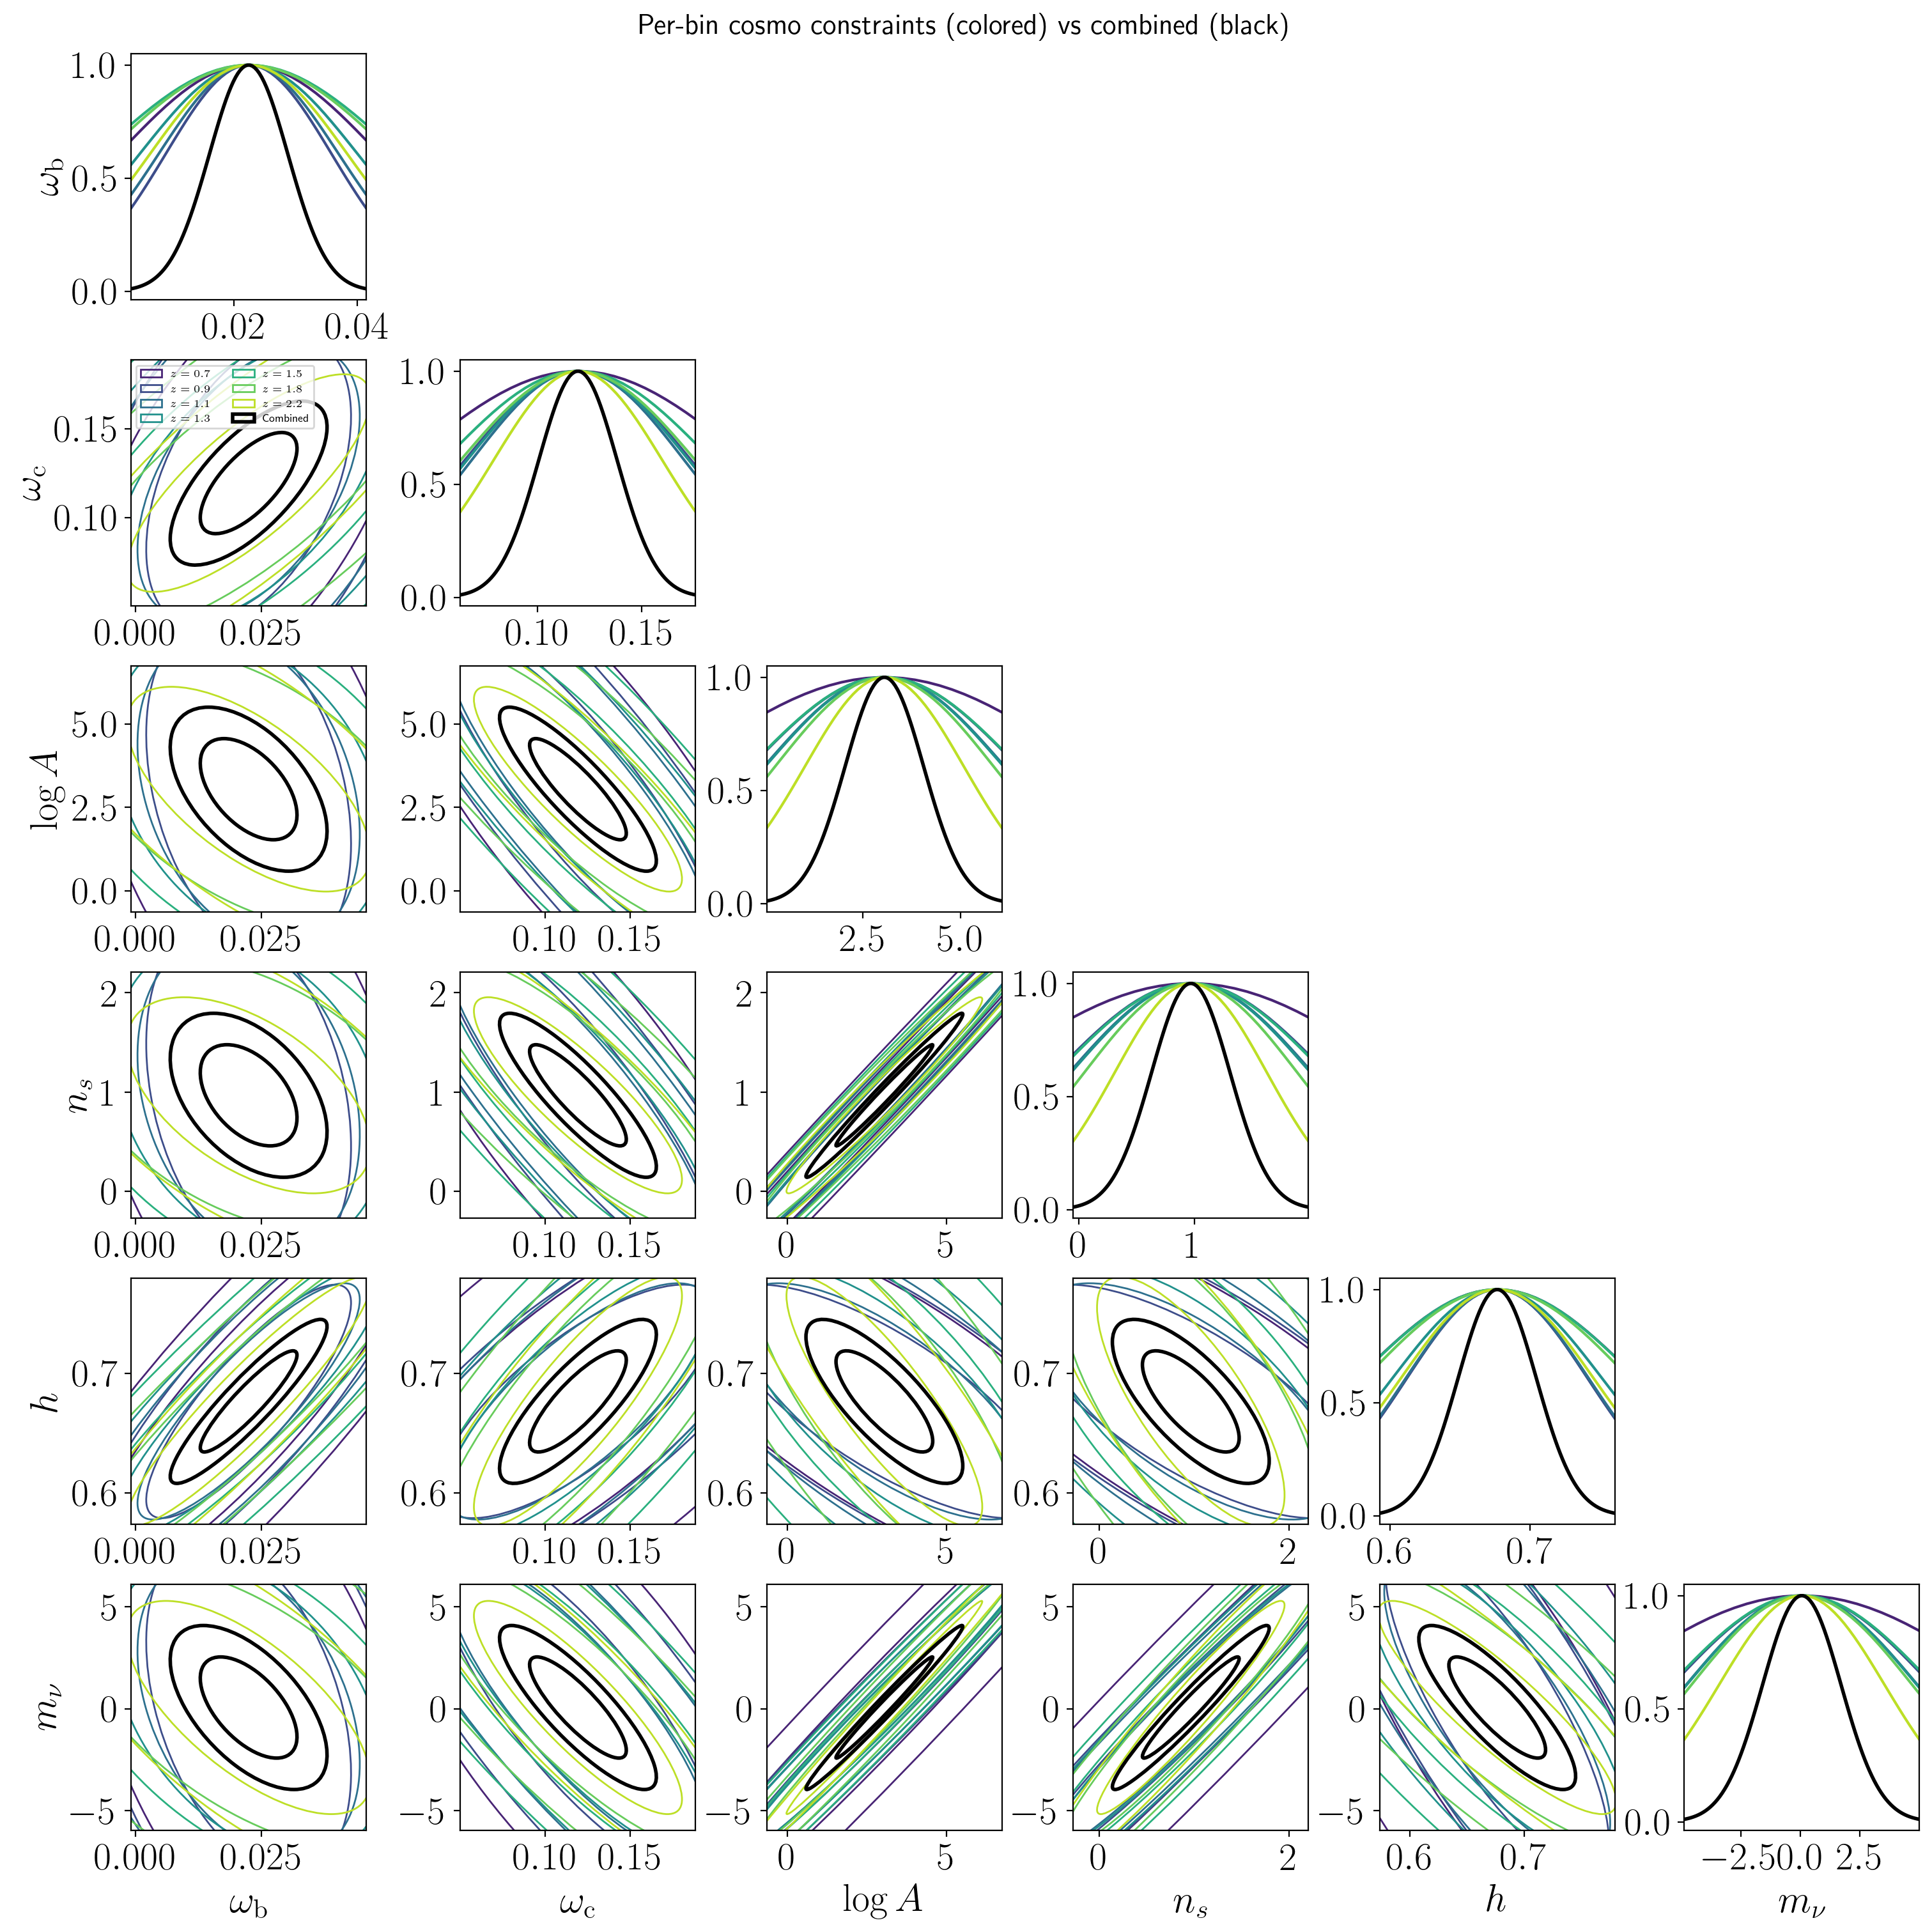

In [14]:
n_plot = len(cosmo_param_names)
fig = plt.figure(figsize=(n_plot*2.5, n_plot*2.5), constrained_layout=True)

colors = cm.viridis(np.linspace(0.1, 0.9, n_zbins))

for i in range(n_plot):
    for j in range(n_plot):
        ax = plt.subplot(n_plot, n_plot, i*n_plot + j + 1)
        if j < i:
            for b in range(n_zbins):
                plot_contours(F_cosmo_per_bin[b], fid_cosmo_varied, np.array([j, i]),
                              fill=False, color=colors[b],
                              label=f'$z={z_bins[b]}$' if (i == 1 and j == 0) else None, cls=[0.68, 0.95], level_kind="mass2d")
            # Combined (all bins)
            plot_contours(F_cosmo_sum, fid_cosmo_varied, np.array([j, i]),
                          fill=False, color='black', lw=2,
                          label='Combined' if (i == 1 and j == 0) else None, cls=[0.68, 0.95], level_kind="mass2d")
            if i == 1 and j == 0:
                # Deduplicate legend entries (plot_contours draws 2 ellipses per call)
                handles, labels = ax.get_legend_handles_labels()
                seen = {}
                for h, l in zip(handles, labels):
                    if l not in seen:
                        seen[l] = h
                ax.legend(seen.values(), seen.keys(), fontsize=6, ncol=2, loc='upper left')
        elif j == i:
            for b in range(n_zbins):
                plot_Gaussian(F_cosmo_per_bin[b], fid_cosmo_varied, i, color=colors[b])
            plot_Gaussian(F_cosmo_sum, fid_cosmo_varied, i, color='black', lw=2)
        else:
            ax.axis('off')
        if i == n_plot - 1: plt.xlabel(cosmo_param_names[j])
        if j == 0: plt.ylabel(cosmo_param_names[i])

fig.suptitle('Per-bin cosmo constraints (colored) vs combined (black)', fontsize=16)

---
# Comparison

In [15]:
print("Marginalized 1-sigma cosmological constraints")
print("=" * 75)
print(f"{'Parameter':>25s}  {'Fiducial':>12s}  {'Method A':>12s}  {'Method B':>12s}  {'Rel. diff':>10s}")
print("-" * 75)

for i, name in enumerate(cosmo_param_names):
    fid = float(fid_cosmo_varied[i])
    sA = float(sigma_A[i])
    sB = float(sigma_B[i])
    rel = abs(sA - sB) / (0.5 * (sA + sB))
    print(f"{name:>25s}  {fid:12.5g}  {sA:12.5g}  {sB:12.5g}  {rel:10.2e}")

print("\nFisher matrix element-wise comparison:")
max_rel = float(jnp.max(jnp.abs(F_cosmo_A - F_cosmo_sum) / (0.5 * jnp.abs(F_cosmo_A + F_cosmo_sum) + 1e-30)))
print(f"  Max relative difference in F_cosmo: {max_rel:.2e}")

Marginalized 1-sigma cosmological constraints
                Parameter      Fiducial      Method A      Method B   Rel. diff
---------------------------------------------------------------------------
      $\omega_\mathrm{b}$       0.02242     0.0063558     0.0063558    4.06e-10
      $\omega_\mathrm{c}$       0.11933      0.018858      0.018858    3.48e-11
                 $\log A$         3.047        1.0049        1.0049    1.41e-10
                    $n_s$        0.9665       0.33743       0.33743    2.08e-10
                      $h$        0.6766      0.028032      0.028032    1.10e-10
                  $m_\nu$          0.06        1.6421        1.6421    4.01e-11

Fisher matrix element-wise comparison:
  Max relative difference in F_cosmo: 9.46e-10


In [16]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(cosmo.param_keys[int(i)] for i in varied_cosmo_idx)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_name='mnu',
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
) + ['mnu']

projection_cases = [
    {'label': 'Method A', 'fisher': F_cosmo_A},
    {'label': 'Method B', 'fisher': F_cosmo_sum},
]

selected_fisher_cases = []
for case in projection_cases:
    projection = project_case_to_specs(
        case['fisher'],
        fid_cosmo_varied,
        np.arange(n_varied_cosmo),
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({**case, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>14s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:14.5g}" if np.isfinite(sigma) else f"  {'---':>14s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial        Method A        Method B
----------------------------------------------------------------
        $\Omega_m$       0.31105        0.028035        0.028035
             $H_0$         67.66          2.8032          2.8032
        $\sigma_8$       0.81034         0.11059         0.11059
      $\sum m_\nu$          0.06          1.6421          1.6421


## Fisher contour comparison

Text(0.5, 0.98, 'Joint (blue) vs per-bin sum (red dashed)')

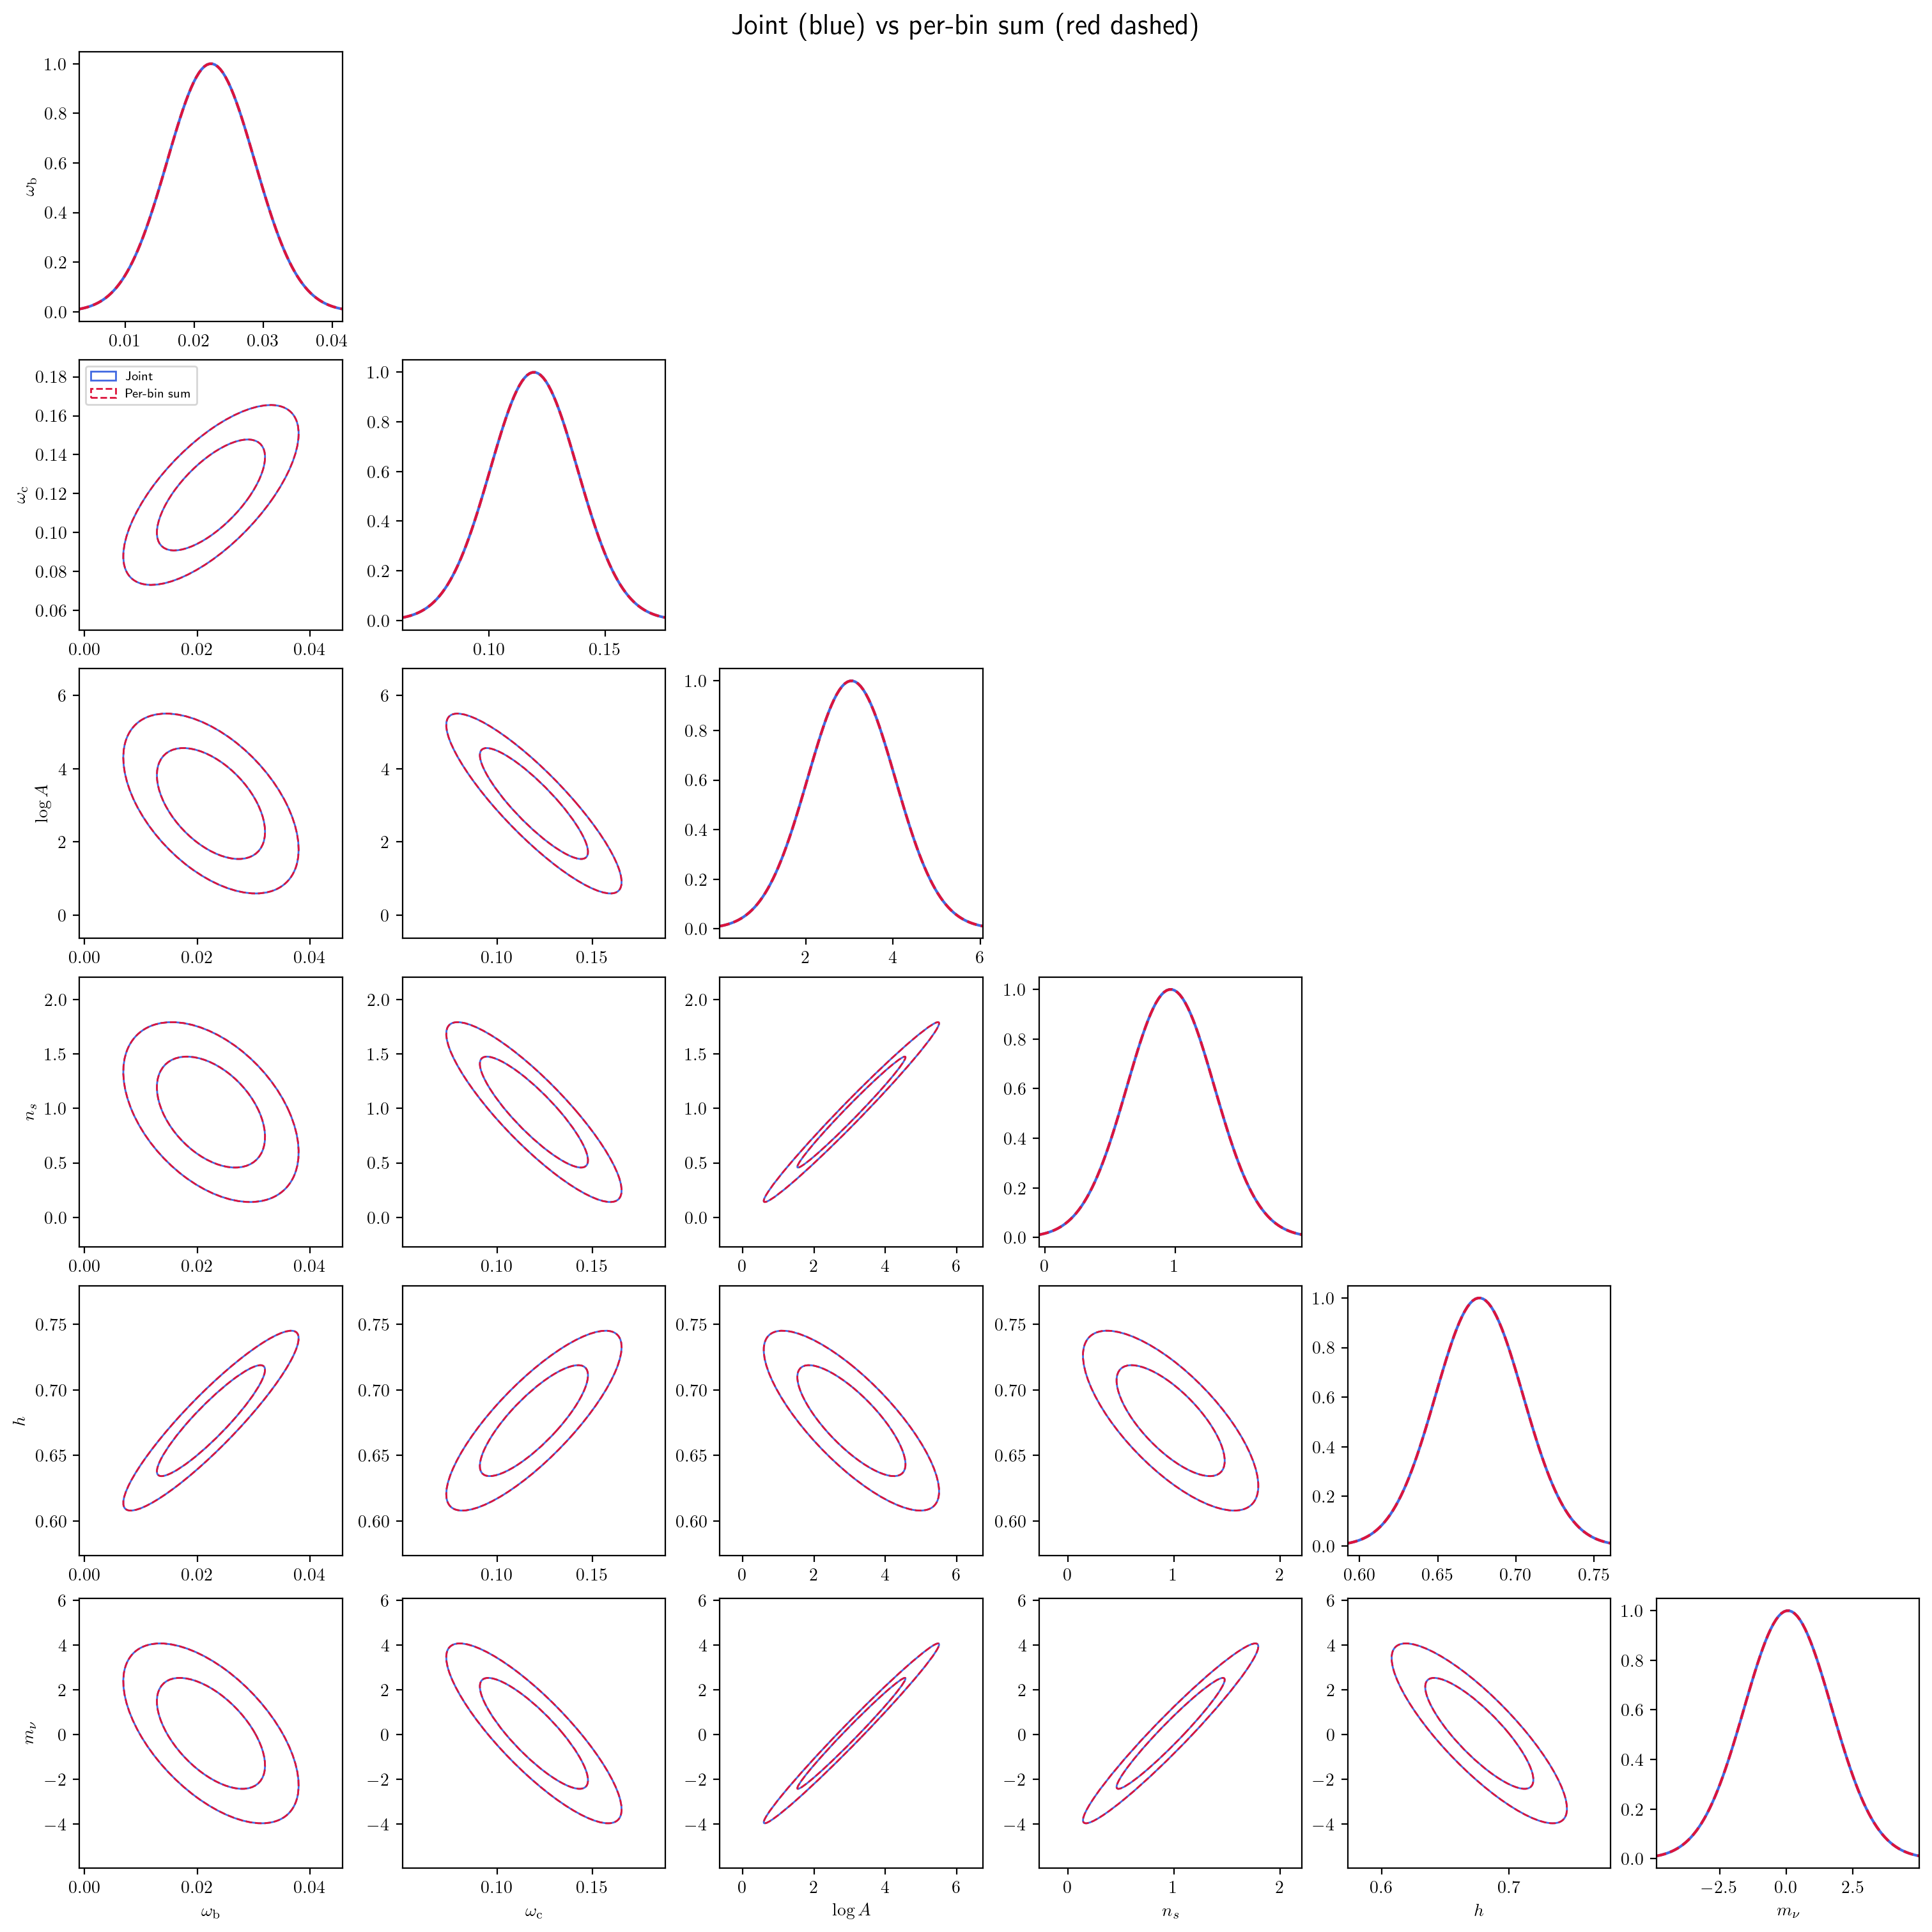

In [17]:
plt.rcParams.update({"font.size": 10})
n_plot = len(cosmo_param_names)
fig = plt.figure(figsize=(n_plot*2.5, n_plot*2.5), constrained_layout=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax = plt.subplot(n_plot, n_plot, i*n_plot + j + 1)
        if j < i:
            plot_contours(F_cosmo_A, fid_cosmo_varied, np.array([j, i]),
                          fill=False, color='royalblue', ls='-', label='Joint', cls=[0.68, 0.95], level_kind="mass2d")
            plot_contours(F_cosmo_sum, fid_cosmo_varied, np.array([j, i]),
                          fill=False, color='crimson', ls='--', label='Per-bin sum', cls=[0.68, 0.95], level_kind="mass2d")
            if i == 1 and j == 0:
                handles, labels = ax.get_legend_handles_labels()
                seen = {}
                for h, l in zip(handles, labels):
                    if l not in seen:
                        seen[l] = h
                ax.legend(seen.values(), seen.keys(), fontsize=7)
        elif j == i:
            plot_Gaussian(F_cosmo_A, fid_cosmo_varied, i, color='royalblue')
            plot_Gaussian(F_cosmo_sum, fid_cosmo_varied, i, color='crimson', ls='--')
        else:
            ax.axis('off')
        if i == n_plot - 1: plt.xlabel(cosmo_param_names[j])
        if j == 0: plt.ylabel(cosmo_param_names[i])

fig.suptitle('Joint (blue) vs per-bin sum (red dashed)', fontsize=16)